# Marketing Mix Modeling


## Phase 2

# Exploratory Data Analysis

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve()))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
raw_data = pd.read_csv("../data/raw/raw_data.csv")

weekly_spends = pd.read_csv("../data/raw/weekly_spends.csv")

raw_data.head()

,State,Week,Salesforce,Email,Website,TV,Meta,Instagram,Influencer,Year,Month,Quarter,Week_Number,Month_End,Quarter_End,Festival,Holiday,Sales
0,Andhra Pradesh,2023-01-02,496,13205,76588,495,522380,1020933,19,2023,1,1,1,False,False,1,1,564
1,Andhra Pradesh,2023-01-09,2003,11825,28198,500,893916,1127800,4,2023,1,1,2,False,False,1,1,720
2,Andhra Pradesh,2023-01-16,1740,4652,57482,404,1433245,1422521,23,2023,1,1,3,False,False,1,1,833
3,Andhra Pradesh,2023-01-23,1265,27191,92730,226,1886417,1309921,23,2023,1,1,4,False,False,1,1,880
4,Andhra Pradesh,2023-01-30,1253,16403,45363,408,1486410,1110026,25,2023,1,1,5,True,False,1,1,870


In [3]:
print(f"Rows : {raw_data.shape[0]}")
print(f"Columns : {raw_data.shape[1]}")

Rows : 4396
Columns : 18


In [4]:
raw_data.columns

Index(['State', 'Week', 'Salesforce', 'Email', 'Website', 'TV', 'Meta',
       'Instagram', 'Influencer', 'Year', 'Month', 'Quarter', 'Week_Number',
       'Month_End', 'Quarter_End', 'Festival', 'Holiday', 'Sales'],
      dtype='str')

In [5]:
raw_data.dtypes

State            str
Week             str
Salesforce     int64
Email          int64
Website        int64
TV             int64
Meta           int64
Instagram      int64
Influencer     int64
Year           int64
Month          int64
Quarter        int64
Week_Number    int64
Month_End       bool
Quarter_End     bool
Festival       int64
Holiday        int64
Sales          int64
dtype: object

In [6]:
raw_data.describe()

,Salesforce,Email,Website,TV,Meta,Instagram,Influencer,Year,Month,Quarter,Week_Number,Festival,Holiday,Sales
count,4396.000000,4396.000000,4396.000000,4396.000000,4.396000e+03,4.396000e+03,4396.000000,4396.000000,4396.000000,4396.000000,4396.000000,4396.000000,4396.000000,4396.000000
mean,1172.584167,17259.678799,52873.424249,242.948817,1.081215e+06,7.908305e+05,13.180846,2024.000000,6.509554,2.503185,26.337580,0.414013,0.414013,759.552320
std,848.531446,13526.281240,39958.835925,170.435799,8.595431e+05,6.222010e+05,10.560010,0.813985,3.463793,1.115304,15.099089,0.492607,0.492607,369.073853
min,63.000000,414.000000,1609.000000,16.000000,2.108400e+04,1.668900e+04,0.000000,2023.000000,1.000000,1.000000,1.000000,0.000000,0.000000,128.000000
25%,489.000000,6593.000000,21598.500000,106.000000,3.996292e+05,2.931442e+05,5.000000,2023.000000,4.000000,2.000000,13.000000,0.000000,0.000000,386.000000
50%,928.500000,12929.500000,40674.000000,196.000000,8.148315e+05,5.991510e+05,10.000000,2024.000000,7.000000,3.000000,26.000000,0.000000,0.000000,759.000000
75%,1713.250000,25707.500000,77276.000000,353.250000,1.619465e+06,1.201522e+06,20.000000,2025.000000,9.000000,3.000000,39.000000,1.000000,1.000000,1046.000000
max,4451.000000,71704.000000,213035.000000,891.000000,4.467549e+06,3.226712e+06,54.000000,2025.000000,12.000000,4.000000,52.000000,1.000000,1.000000,2124.000000


In [7]:
raw_data.isnull().sum()

State          0
Week           0
Salesforce     0
Email          0
Website        0
TV             0
Meta           0
Instagram      0
Influencer     0
Year           0
Month          0
Quarter        0
Week_Number    0
Month_End      0
Quarter_End    0
Festival       0
Holiday        0
Sales          0
dtype: int64

In [8]:
raw_data.duplicated().sum()

np.int64(0)

In [9]:
raw_data["Week"] = pd.to_datetime(raw_data["Week"])

## National Weekly Sales Trend

Objective:
- Understand the sales trend over time.
- Identify seasonality.
- Detect unusual spikes or drops.
- Check whether sales exhibit an increasing, decreasing or stable trend.

In [10]:
# National Weekly Sales

weekly_sales = (
    raw_data
    .groupby("Week")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Week,Sales
0,2023-01-02,13110
1,2023-01-09,17802
2,2023-01-16,19438
3,2023-01-23,19960
4,2023-01-30,21203


In [11]:
# 4-week Moving Average

weekly_sales["Moving_Average"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
)

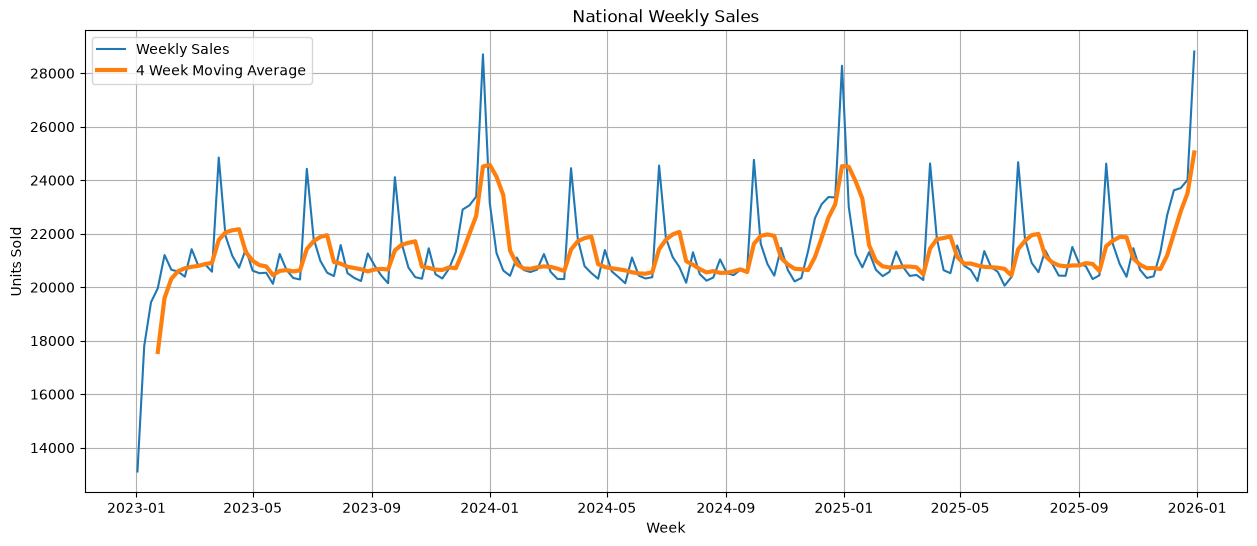

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.plot(
    weekly_sales["Week"],
    weekly_sales["Moving_Average"],
    linewidth=3,
    label="4 Week Moving Average"
)

plt.title("National Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Units Sold")

plt.legend()

plt.grid(True)

plt.show()

### Business Observations

- Sales remain relatively stable across the three-year period.
- Quarter-end periods show noticeable increases due to the simulated seasonality.
- Month-end uplifts create recurring short-term peaks.
- No prolonged declining trend is observed.
- The moving average indicates a healthy and consistent business.

## Marketing Channel Activity Trends

Objective:

Understand how each marketing channel varies over time before building the Marketing Mix Model.

In [13]:
weekly_channels = (
    raw_data
    .groupby("Week")[
        [
            "Salesforce",
            "Email",
            "Website",
            "TV",
            "Meta",
            "Instagram",
            "Influencer"
        ]
    ]
    .sum()
)

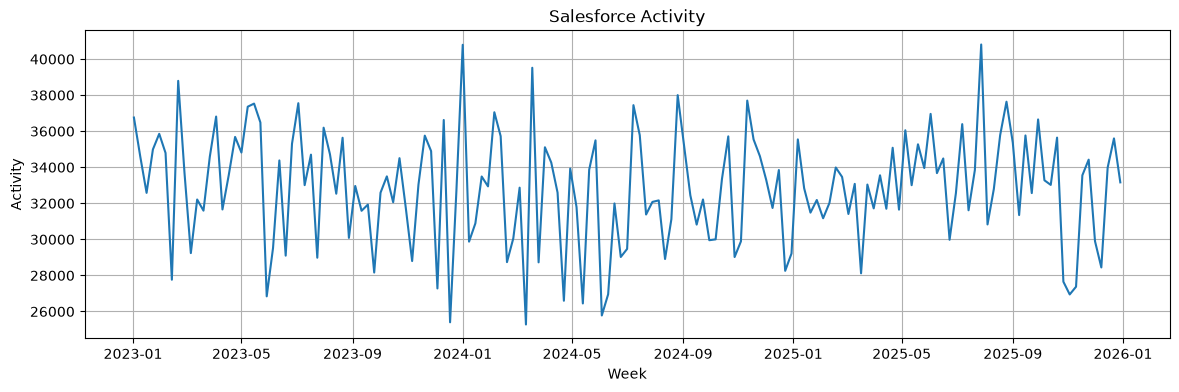

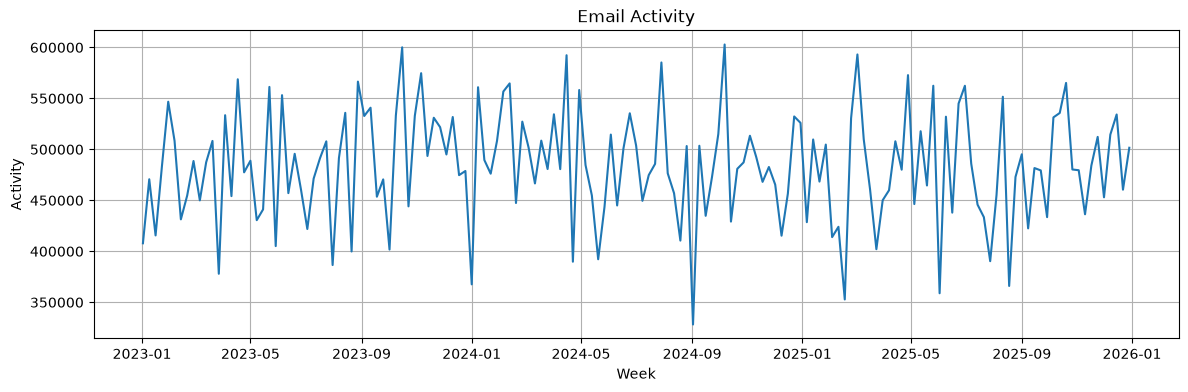

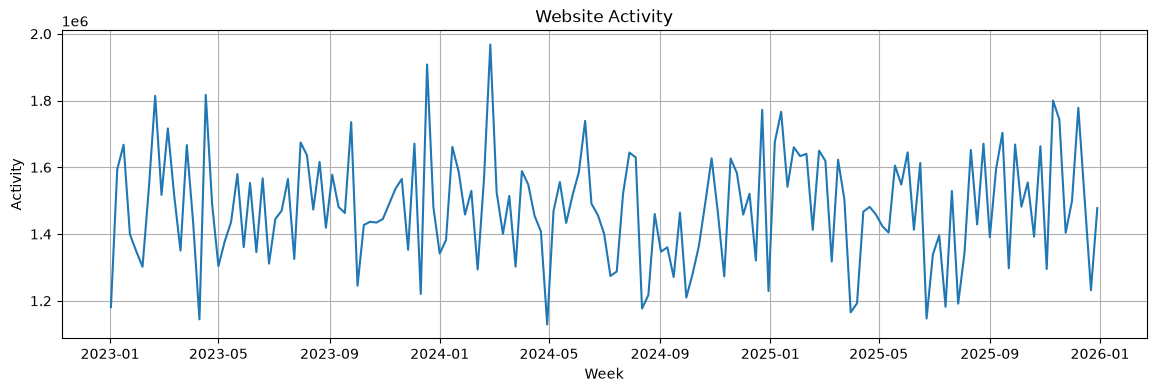

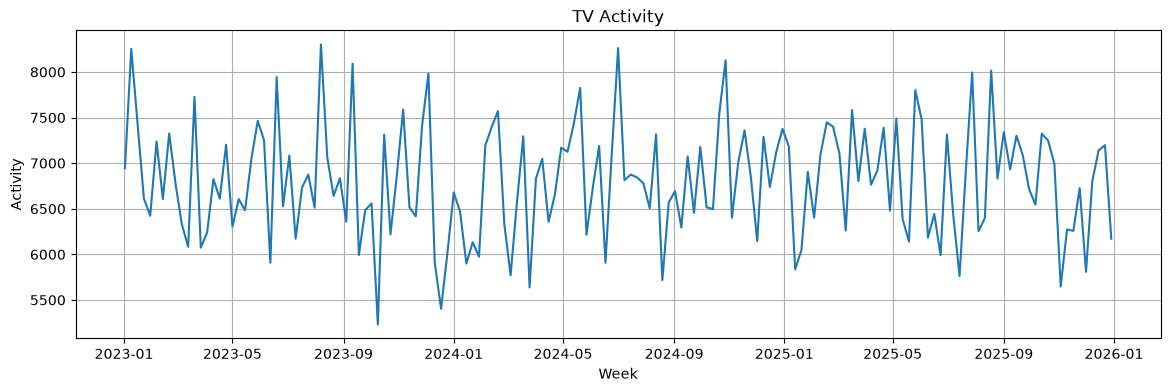

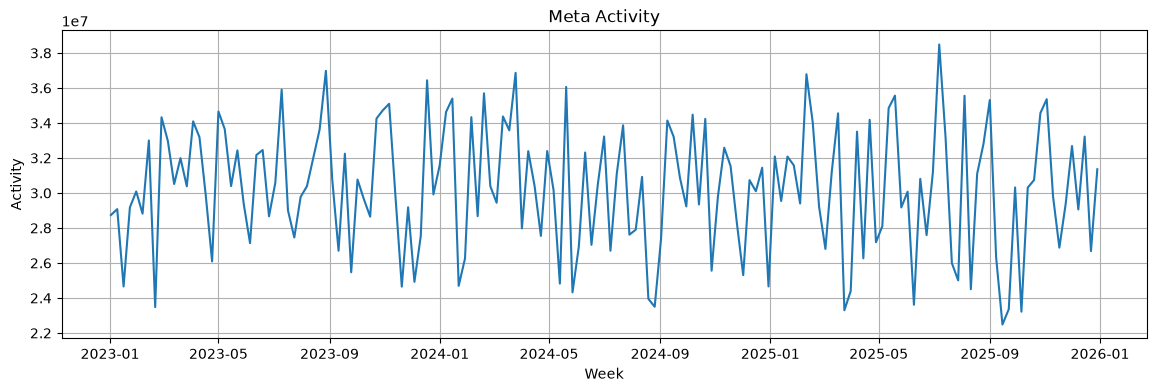

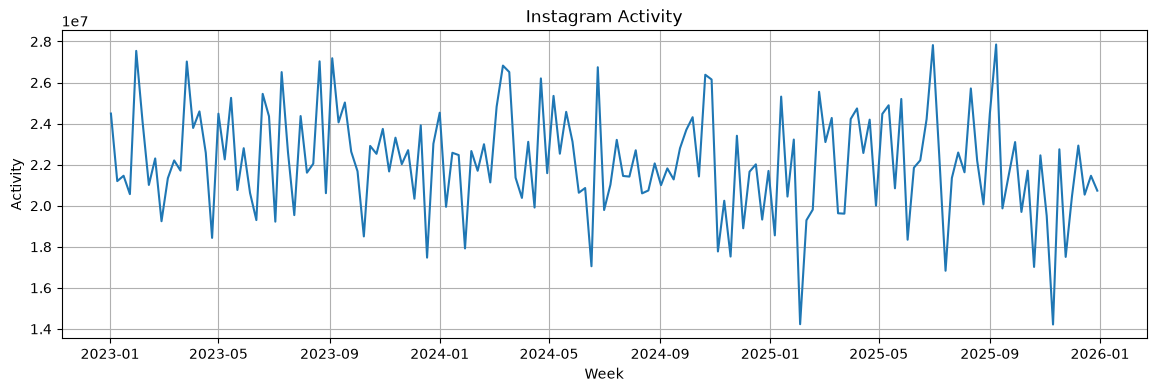

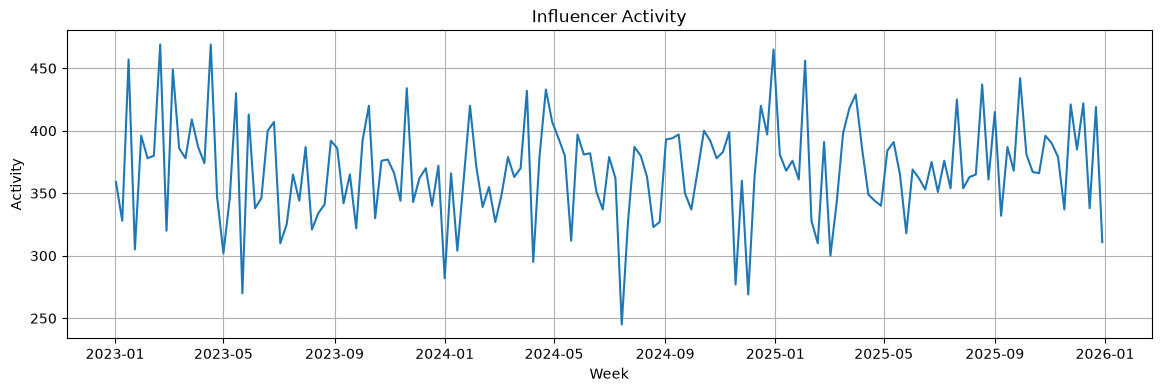

In [14]:
for channel in weekly_channels.columns:

    plt.figure(figsize=(14,4))

    plt.plot(
        weekly_channels.index,
        weekly_channels[channel]
    )

    plt.title(f"{channel} Activity")

    plt.xlabel("Week")

    plt.ylabel("Activity")

    plt.grid(True)

    plt.show()

### Business Observations

- Salesforce remains relatively consistent over time.
- Digital channels exhibit higher week-to-week variability.
- TV activity fluctuates more significantly, reflecting campaign scheduling.
- No channels exhibit missing periods or abnormal discontinuities.

## Average Sales by State

In [15]:
state_sales = (
    raw_data
    .groupby("State")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

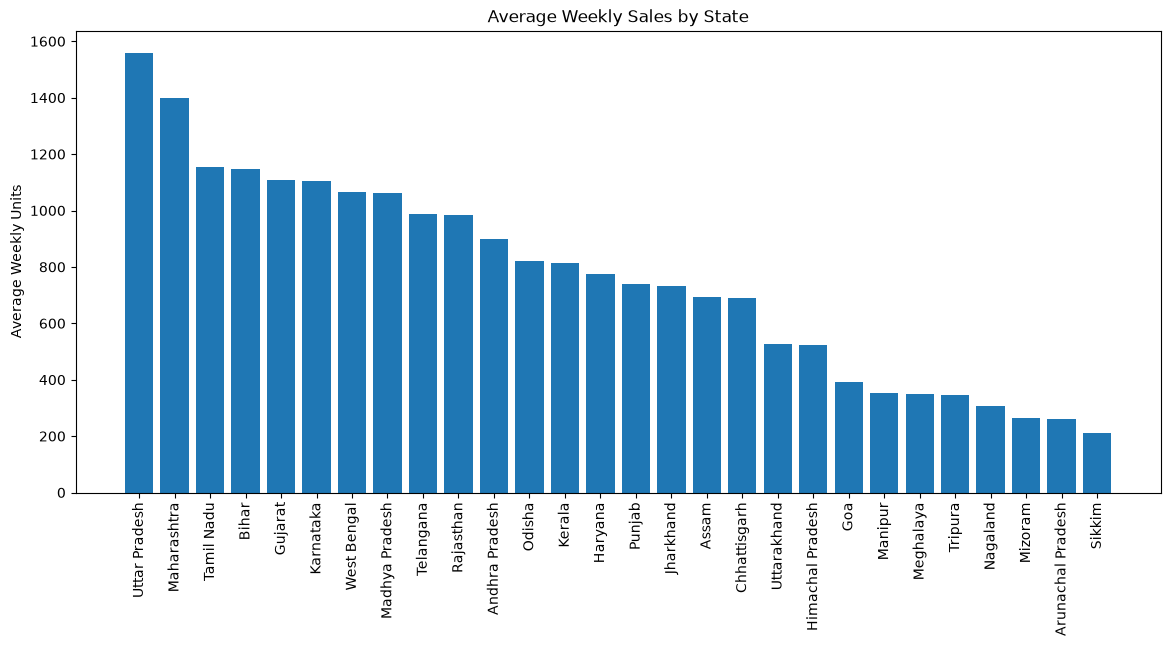

In [16]:
plt.figure(figsize=(14,6))

plt.bar(
    state_sales.index,
    state_sales.values
)

plt.xticks(rotation=90)

plt.ylabel("Average Weekly Units")

plt.title("Average Weekly Sales by State")

plt.show()

### Business Observations

- Larger markets contribute substantially higher average sales.
- State differences align with the synthetic baseline demand.
- No unexpected outlier states are observed.

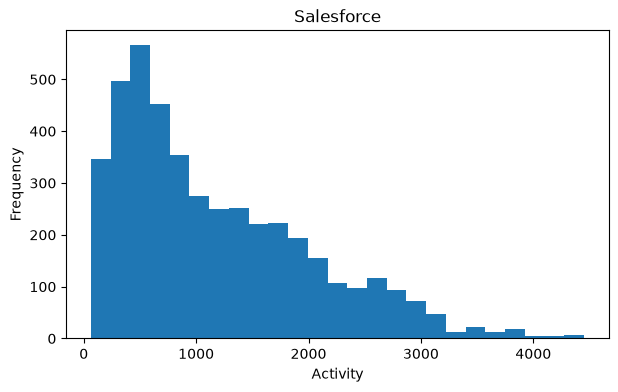

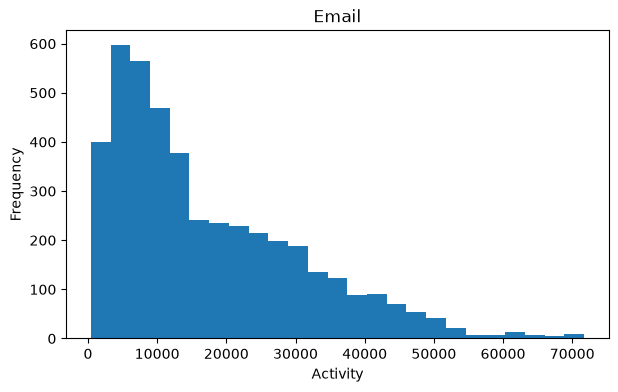

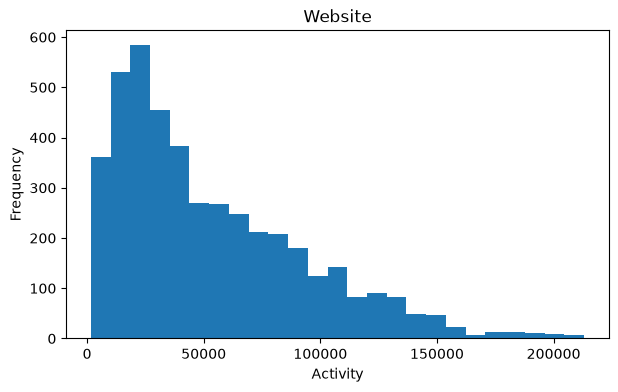

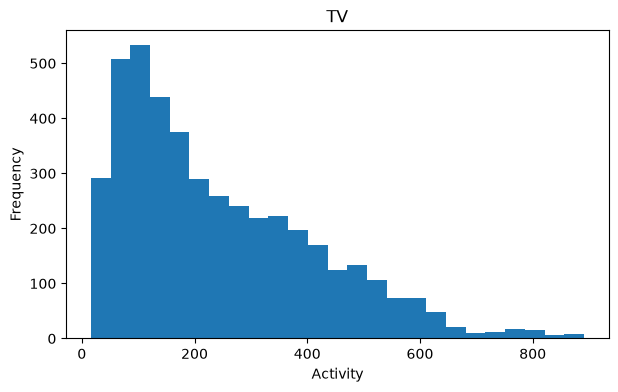

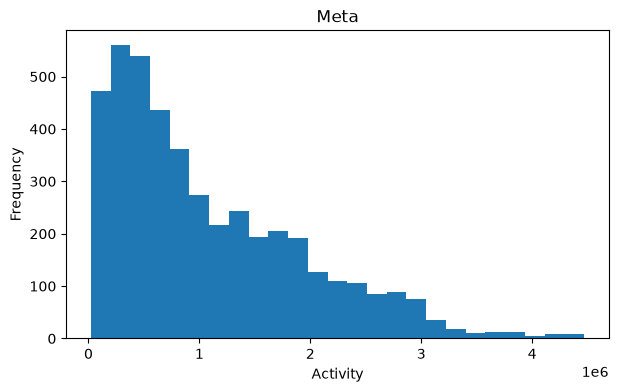

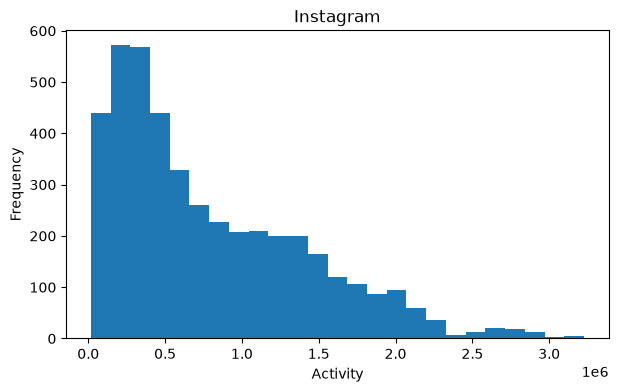

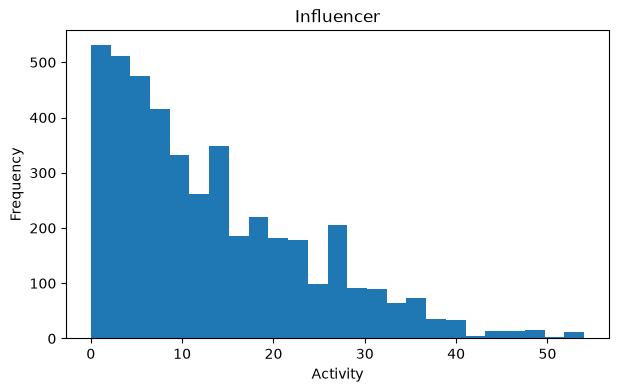

In [17]:
channels = [
    "Salesforce",
    "Email",
    "Website",
    "TV",
    "Meta",
    "Instagram",
    "Influencer"
]

for channel in channels:

    plt.figure(figsize=(7,4))

    plt.hist(
        raw_data[channel],
        bins=25
    )

    plt.title(channel)

    plt.xlabel("Activity")

    plt.ylabel("Frequency")

    plt.show()

In [18]:
corr = raw_data[
    [
        "Sales",
        "Salesforce",
        "Email",
        "Website",
        "TV",
        "Meta",
        "Instagram",
        "Influencer"
    ]
].corr()

corr

,Sales,Salesforce,Email,Website,TV,Meta,Instagram,Influencer
Sales,1.000000,0.703859,0.639168,0.642426,0.731438,0.632779,0.650241,0.663937
Salesforce,0.703859,1.000000,0.450841,0.469401,0.547319,0.457823,0.476362,0.465240
Email,0.639168,0.450841,1.000000,0.415524,0.486440,0.432923,0.427312,0.428194
Website,0.642426,0.469401,0.415524,1.000000,0.486144,0.409359,0.415895,0.436317
TV,0.731438,0.547319,0.486440,0.486144,1.000000,0.472458,0.500693,0.497786
Meta,0.632779,0.457823,0.432923,0.409359,0.472458,1.000000,0.443123,0.435253
Instagram,0.650241,0.476362,0.427312,0.415895,0.500693,0.443123,1.000000,0.444129
Influencer,0.663937,0.465240,0.428194,0.436317,0.497786,0.435253,0.444129,1.000000


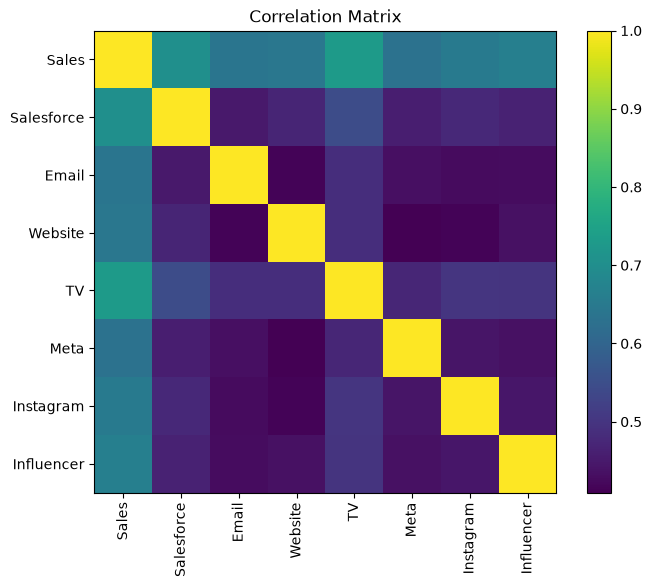

In [19]:
plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

### Business Observations

- Positive correlations are expected because all channels contribute positively to sales.
- Correlation alone should not be interpreted as causal impact.
- Adstock and transformation effects are not yet reflected in this analysis.
- Feature engineering in the next phase will refine these relationships before model estimation.